# Charcoal KBr FTIR Reference Analysis

Objective: build a runnable analysis walkthrough for charcoal and biochar FTIR reference data, with figures we can use in a presentation about KBr-pellet charcoal references and possible FTIR-EC underestimation for wood-burning/charcoal-rich aerosol.

Success criteria:
- Load downloaded reference spectra without committing raw data.
- Visualize what charcoal spectra look like across charring temperatures.
- Summarize diagnostic FTIR regions for charcoal/biochar comparison.
- Provide a place to overlay our lab KBr pellet spectra once exported.

## Working Hypothesis

High-temperature charcoal and binchotan-like material should show weaker oxygenated/aliphatic organic features than lower-temperature hardwood lump charcoal. If Addis filters contain charcoal-like material, an FTIR-EC calibration trained mostly on other carbon mixtures may underpredict that fraction. This notebook does not prove that yet; it builds the reference visual framework for testing it.

In [1]:
from pathlib import Path
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=UserWarning)


def find_project_dir() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [
        cwd,
        cwd.parent,
        cwd / 'research' / 'charcoal_ftir',
        cwd.parent / 'research' / 'charcoal_ftir',
    ]
    for candidate in candidates:
        if (candidate / 'sources.json').exists() and (candidate / 'data').exists():
            return candidate
    raise FileNotFoundError('Could not find research/charcoal_ftir. Run from repo root or notebook folder.')

PROJECT_DIR = find_project_dir()
RAW_DIR = PROJECT_DIR / 'data' / 'raw'
OUTPUT_DIR = PROJECT_DIR / 'output'
PLOT_DIR = OUTPUT_DIR / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.figsize': (11, 6),
    'figure.dpi': 120,
    'savefig.dpi': 220,
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.22,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

FEATURE_REGIONS = [
    {'name': 'O-H / moisture', 'low': 3200, 'high': 3600, 'color': '#4C78A8'},
    {'name': 'Aliphatic C-H', 'low': 2800, 'high': 3000, 'color': '#F58518'},
    {'name': 'C=O / aromatic shoulder', 'low': 1650, 'high': 1750, 'color': '#E45756'},
    {'name': 'Aromatic C=C', 'low': 1500, 'high': 1650, 'color': '#72B7B2'},
    {'name': 'C-O / mineral overlap', 'low': 1000, 'high': 1300, 'color': '#54A24B'},
]

print(f'Project dir: {PROJECT_DIR}')
print(f'Raw data dir exists: {RAW_DIR.exists()}')
print(f'Plots will save to: {PLOT_DIR}')

Project dir: /Users/ahmadjalil/github/aethmodular/research/charcoal_ftir
Raw data dir exists: True
Plots will save to: /Users/ahmadjalil/github/aethmodular/research/charcoal_ftir/output/plots


## Source Inventory

The raw datasets live under `data/raw/`, which is git-ignored. The notebook uses `sources.json` to summarize the reference library and then loads a few high-value datasets for plotting.

In [2]:
with open(PROJECT_DIR / 'sources.json', 'r') as f:
    sources = json.load(f)['sources']

inventory = pd.DataFrame([
    {
        'id': s['id'],
        'kind': s.get('kind'),
        'title': s.get('title'),
        'notes': s.get('notes'),
        'repository_url': s.get('repository_url'),
    }
    for s in sources
])

display(inventory[['id', 'kind', 'title', 'notes']])

,id,kind,title,notes
0,minatre_dryad_charcoal_temperature,dryad,Data from: Charcoal analysis for temperature r...,"Charcoal transmission FTIR spectra, 950-3500 c..."
1,gosling_figshare_charcoal_temperature,figshare,Data from: Reconstructing past fire temperatur...,Modern reference charcoal and ancient charcoal...
2,maezumi_zenodo_charcoal_analog,zenodo,A modern analogue matching approach to charact...,R code and FTIR chemical spectra of reference ...
3,mccall_acs_figshare_biochar_stability,figshare,Biochar Stability Revealed by FTIR and Machine...,ATR-FTIR biochar spectra and stability-ratio d...
4,barbosa_figshare_sewage_sludge_biochar,figshare,Biochar from sewage sludge: effect of pyrolysi...,Raw paper data; this downloader pulls the FTIR...
5,tigalana_mendeley_rice_straw_biochar_pb,mendeley,Pb(II) adsorption by KOH-modified rice straw b...,FTIR CSV spectra for pristine rice-straw bioch...
6,zeba_dataone_pine_pyom_ageing,dataone,Aged and unaged pine wood pyrogenic organic ma...,"PyOM mineralization, elemental analysis, and F..."
7,epa_direct_soil_ftir,direct,Fourier Transformed Infrared (FTIR) Spectrosco...,Soil FTIR workbook from EPA/Data.gov; useful b...
8,mnhn_zenodo_atr_ftir_database,zenodo,"ATR-FTIR spectral database of geological, expe...",Open ATR-FTIR reference library with sample-in...
9,pereira_ufscar_binchotan_thesis,direct,Binchotan charcoal as a renewable source for p...,Binchotan thesis with extractable text and emb...


## KBr Pellet Prep Calculator

Protocol target from the lab notes: about 0.4-0.5 mg charcoal with 300 mg KBr. These calculations help document the dilution and pellet charcoal wt% for methods slides.

In [3]:
kbr = pd.DataFrame({
    'charcoal_mg': [0.4, 0.5],
    'kbr_mg': [300.0, 300.0],
})
kbr['total_pellet_mg'] = kbr['charcoal_mg'] + kbr['kbr_mg']
kbr['charcoal_wt_percent'] = 100 * kbr['charcoal_mg'] / kbr['total_pellet_mg']
kbr['kbr_to_charcoal_ratio'] = kbr['kbr_mg'] / kbr['charcoal_mg']
display(kbr)

,charcoal_mg,kbr_mg,total_pellet_mg,charcoal_wt_percent,kbr_to_charcoal_ratio
0,0.4,300.0,300.4,0.133156,750.0
1,0.5,300.0,300.5,0.166389,600.0


## Helper Functions

These functions normalize the different file shapes:
- wide spectra: one row per sample and one column per wavenumber.
- JASCO CSV: metadata followed by an `XYDATA` block.
- feature summaries: average intensity over diagnostic FTIR bands.

In [4]:
def wavenumber_from_column(col):
    text = str(col)
    base = re.sub(r'\.\d+$', '', text)
    try:
        value = float(base)
    except ValueError:
        return None
    if 100 <= value <= 5000:
        return value
    return None


def load_wide_spectra_csv(path, nrows=None):
    df = pd.read_csv(path, nrows=nrows)
    wn_cols = [c for c in df.columns if wavenumber_from_column(c) is not None]
    meta_cols = [c for c in df.columns if c not in wn_cols]
    wn = np.array([wavenumber_from_column(c) for c in wn_cols], dtype=float)
    y = df[wn_cols].apply(pd.to_numeric, errors='coerce').to_numpy(dtype=float)
    order = np.argsort(wn)
    return df[meta_cols].copy(), wn[order], y[:, order]


def load_wide_spectra_excel(path, sheet_name=0):
    df = pd.read_excel(path, sheet_name=sheet_name)
    wn_cols = [c for c in df.columns if wavenumber_from_column(c) is not None]
    meta_cols = [c for c in df.columns if c not in wn_cols]
    wn = np.array([wavenumber_from_column(c) for c in wn_cols], dtype=float)
    y = df[wn_cols].apply(pd.to_numeric, errors='coerce').to_numpy(dtype=float)
    order = np.argsort(wn)
    return df[meta_cols].copy(), wn[order], y[:, order]


def normalize_rows(y):
    arr = np.array(y, dtype=float)
    row_min = np.nanmin(arr, axis=1, keepdims=True)
    row_max = np.nanmax(arr, axis=1, keepdims=True)
    denom = np.where((row_max - row_min) == 0, 1, row_max - row_min)
    return (arr - row_min) / denom


def shade_feature_regions(ax, ymax=1.0, label=True):
    for region in FEATURE_REGIONS:
        ax.axvspan(region['low'], region['high'], color=region['color'], alpha=0.10, lw=0)
        if label:
            ax.text(
                (region['low'] + region['high']) / 2,
                ymax,
                region['name'],
                ha='center',
                va='top',
                rotation=90,
                fontsize=8,
                color=region['color'],
            )


def save_current_fig(name):
    path = PLOT_DIR / name
    plt.savefig(path, bbox_inches='tight')
    print(f'Saved {path}')
    return path


def extract_region_features(wn, y_norm, metadata, group_col=None):
    rows = []
    for idx in range(y_norm.shape[0]):
        base = metadata.iloc[idx].to_dict()
        for region in FEATURE_REGIONS:
            mask = (wn >= region['low']) & (wn <= region['high'])
            rows.append({
                **base,
                'feature': region['name'],
                'low_cm-1': region['low'],
                'high_cm-1': region['high'],
                'relative_intensity': float(np.nanmean(y_norm[idx, mask])),
            })
    out = pd.DataFrame(rows)
    if group_col and group_col in out.columns:
        return out.groupby([group_col, 'feature'], as_index=False)['relative_intensity'].mean()
    return out


def read_jasco_xy_csv(path):
    lines = Path(path).read_text(errors='replace').splitlines()
    try:
        start = next(i for i, line in enumerate(lines) if line.strip().upper() == 'XYDATA') + 1
    except StopIteration as exc:
        raise ValueError(f'Could not find XYDATA block in {path}') from exc
    data = []
    for line in lines[start:]:
        if not line.strip() or ',' not in line:
            continue
        left, right = line.split(',', 1)
        try:
            data.append((float(left.strip()), float(right.strip())))
        except ValueError:
            continue
    return pd.DataFrame(data, columns=['wavenumber', 'transmittance'])


def parse_mean(value):
    text = str(value).replace(',', '')
    text = text.split('+-')[0].split('\u00b1')[0].split('~')[0]
    try:
        return float(text)
    except ValueError:
        return np.nan

## Minatre / Dryad Charcoal Temperature Spectra

This is the strongest full spectral dataset in the local collection. It covers reference chars across charring temperatures and woody species. The plot below averages normalized spectra by temperature to show the broad temperature gradient.

In [5]:
minatre_path = RAW_DIR / 'minatre_dryad_charcoal_temperature' / 'Minatre_reference_spectra.csv'
minatre_meta, minatre_wn, minatre_y = load_wide_spectra_csv(minatre_path)
minatre_meta = minatre_meta.rename(columns={'Species': 'species', 'Temperature': 'temperature'})
minatre_y_norm = normalize_rows(minatre_y)

summary = (
    minatre_meta
    .groupby('temperature')
    .agg(n_spectra=('species', 'size'), n_species=('species', 'nunique'))
    .reset_index()
)
display(summary)
print(f'Spectra matrix: {minatre_y_norm.shape[0]} spectra x {minatre_y_norm.shape[1]} wavenumber columns')
print(f'Wavenumber range: {minatre_wn.min():.0f}-{minatre_wn.max():.0f} cm-1')

,temperature,n_spectra,n_species
0,200,300,10
1,300,300,10
2,400,300,10
3,500,300,10
4,600,300,10
5,700,300,10
6,800,300,10


Spectra matrix: 2100 spectra x 2646 wavenumber columns
Wavenumber range: 950-3500 cm-1


Saved /Users/ahmadjalil/github/aethmodular/research/charcoal_ftir/output/plots/minatre_temperature_series.png


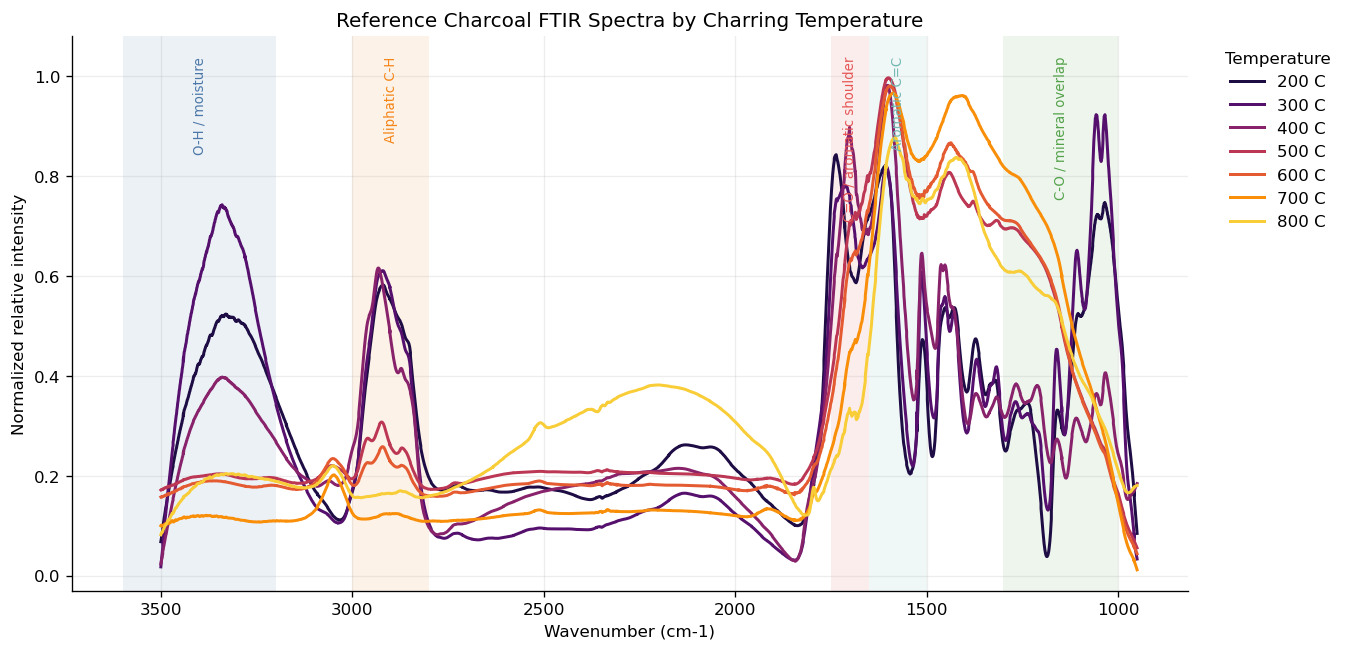

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
temps = sorted(minatre_meta['temperature'].dropna().unique())
colors = plt.cm.inferno(np.linspace(0.12, 0.88, len(temps)))

for color, temp in zip(colors, temps):
    mask = minatre_meta['temperature'].to_numpy() == temp
    mean_spectrum = np.nanmean(minatre_y_norm[mask], axis=0)
    ax.plot(minatre_wn, mean_spectrum, color=color, lw=1.8, label=f'{int(temp)} C')

shade_feature_regions(ax, ymax=1.04)
ax.set_title('Reference Charcoal FTIR Spectra by Charring Temperature')
ax.set_xlabel('Wavenumber (cm-1)')
ax.set_ylabel('Normalized relative intensity')
ax.invert_xaxis()
ax.set_ylim(-0.03, 1.08)
ax.legend(title='Temperature', ncol=1, frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left')
save_current_fig('minatre_temperature_series.png')
plt.show()

## Diagnostic Region Summary

This plot compresses each spectrum into a few interpretable FTIR regions. Use it as a first-pass presentation figure, not a final calibration model. Relative intensity direction can depend on preprocessing and measurement mode, so compare within a dataset unless we reprocess all spectra consistently.

Saved /Users/ahmadjalil/github/aethmodular/research/charcoal_ftir/output/plots/minatre_feature_intensity_by_temperature.png


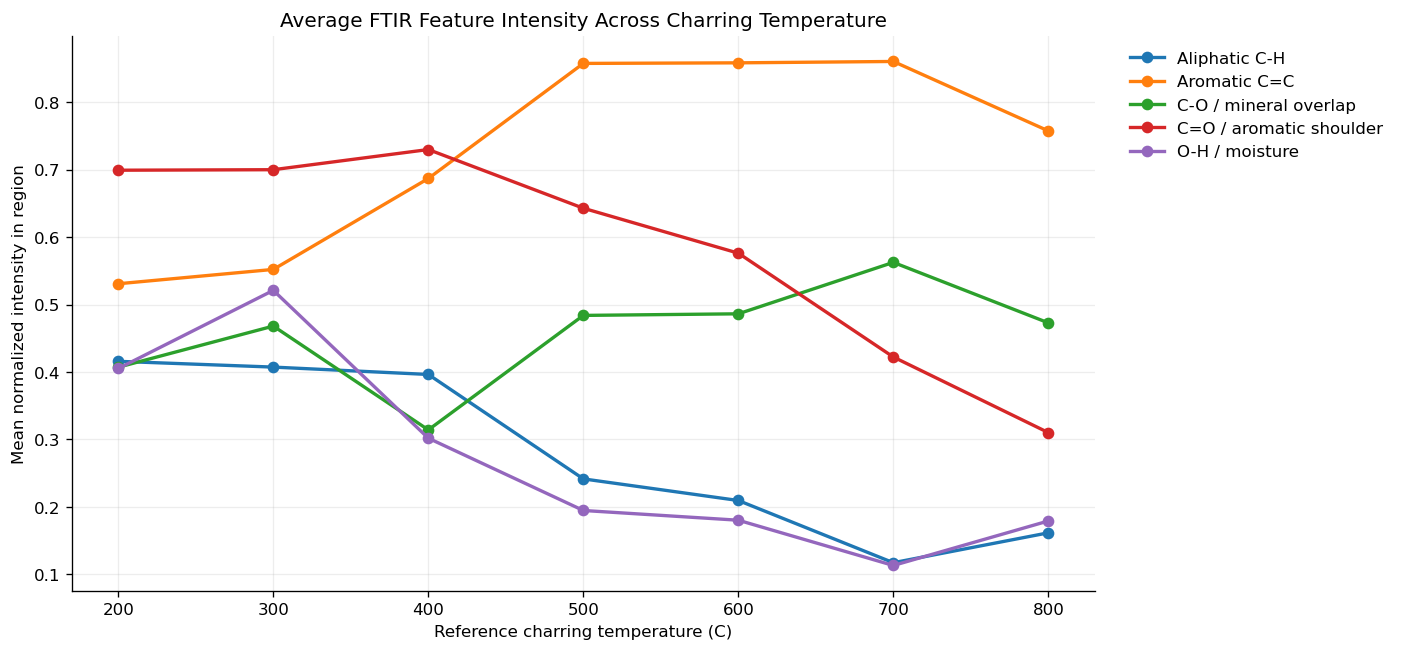

feature,Aliphatic C-H,Aromatic C=C,C-O / mineral overlap,C=O / aromatic shoulder,O-H / moisture
temperature,,,,,
200,0.416,0.531,0.407,0.699,0.405
300,0.407,0.552,0.468,0.700,0.521
400,0.396,0.687,0.314,0.730,0.302
500,0.241,0.858,0.484,0.643,0.195
600,0.209,0.859,0.486,0.576,0.180
700,0.117,0.861,0.563,0.422,0.113
800,0.161,0.758,0.473,0.310,0.179


In [7]:
minatre_features = extract_region_features(
    minatre_wn,
    minatre_y_norm,
    minatre_meta[['species', 'temperature']],
    group_col='temperature',
)

fig, ax = plt.subplots(figsize=(11, 6))
for feature, group in minatre_features.groupby('feature'):
    ax.plot(group['temperature'], group['relative_intensity'], marker='o', lw=2, label=feature)

ax.set_title('Average FTIR Feature Intensity Across Charring Temperature')
ax.set_xlabel('Reference charring temperature (C)')
ax.set_ylabel('Mean normalized intensity in region')
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left')
save_current_fig('minatre_feature_intensity_by_temperature.png')
plt.show()

display(minatre_features.pivot(index='temperature', columns='feature', values='relative_intensity').round(3))

## Low-Dimensional Map of Reference Charcoals

A quick PCA-style map on binned spectra gives a visual reference space for unknown KBr pellet spectra. Later, lab spectra can be projected into the same preprocessing workflow.

Saved /Users/ahmadjalil/github/aethmodular/research/charcoal_ftir/output/plots/minatre_reference_spectral_map.png


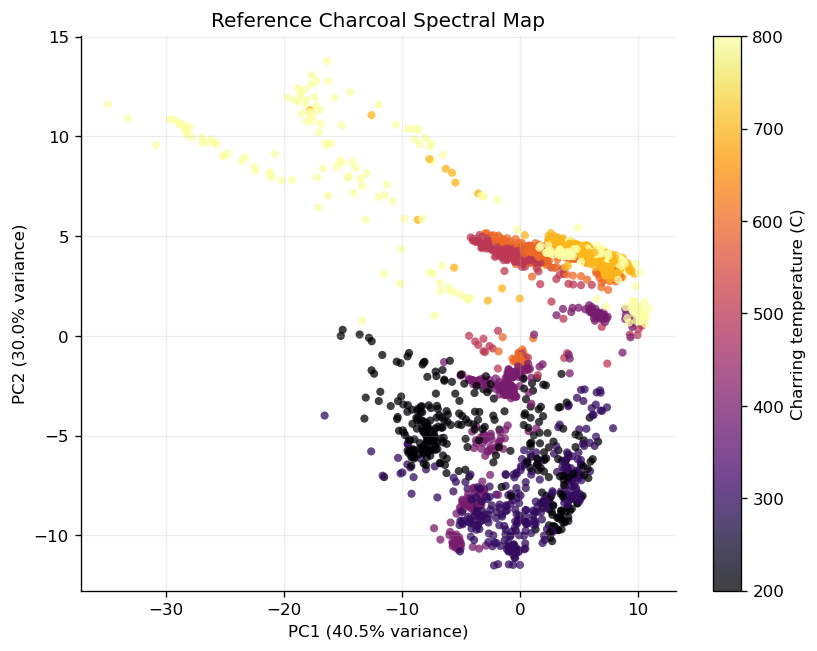

In [8]:
def bin_spectra(wn, y, bin_width=25):
    bins = np.arange(np.floor(wn.min() / bin_width) * bin_width, np.ceil(wn.max() / bin_width) * bin_width + bin_width, bin_width)
    centers = []
    values = []
    for low, high in zip(bins[:-1], bins[1:]):
        mask = (wn >= low) & (wn < high)
        if mask.sum() < 1:
            continue
        centers.append((low + high) / 2)
        values.append(np.nanmean(y[:, mask], axis=1))
    return np.array(centers), np.vstack(values).T

binned_wn, minatre_binned = bin_spectra(minatre_wn, minatre_y_norm, bin_width=25)
X = minatre_binned.copy()
X = X - np.nanmean(X, axis=0, keepdims=True)
scale = np.nanstd(X, axis=0, keepdims=True)
scale[scale == 0] = 1
X = np.nan_to_num(X / scale)
U, S, Vt = np.linalg.svd(X, full_matrices=False)
scores = U[:, :2] * S[:2]
var = (S ** 2) / np.sum(S ** 2)

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    scores[:, 0],
    scores[:, 1],
    c=minatre_meta['temperature'],
    cmap='inferno',
    s=24,
    alpha=0.75,
    edgecolor='none',
)
ax.set_title('Reference Charcoal Spectral Map')
ax.set_xlabel(f'PC1 ({var[0] * 100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({var[1] * 100:.1f}% variance)')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Charring temperature (C)')
save_current_fig('minatre_reference_spectral_map.png')
plt.show()

## Tigalana Rice-Straw Biochar: Before/After Modification and Pb Loading

These files are useful because they are simple XY spectra. They are not KBr pellet charcoal references, but they show how biochar FTIR features move after chemical modification and metal loading.

Saved /Users/ahmadjalil/github/aethmodular/research/charcoal_ftir/output/plots/tigalana_biochar_treatment_comparison.png


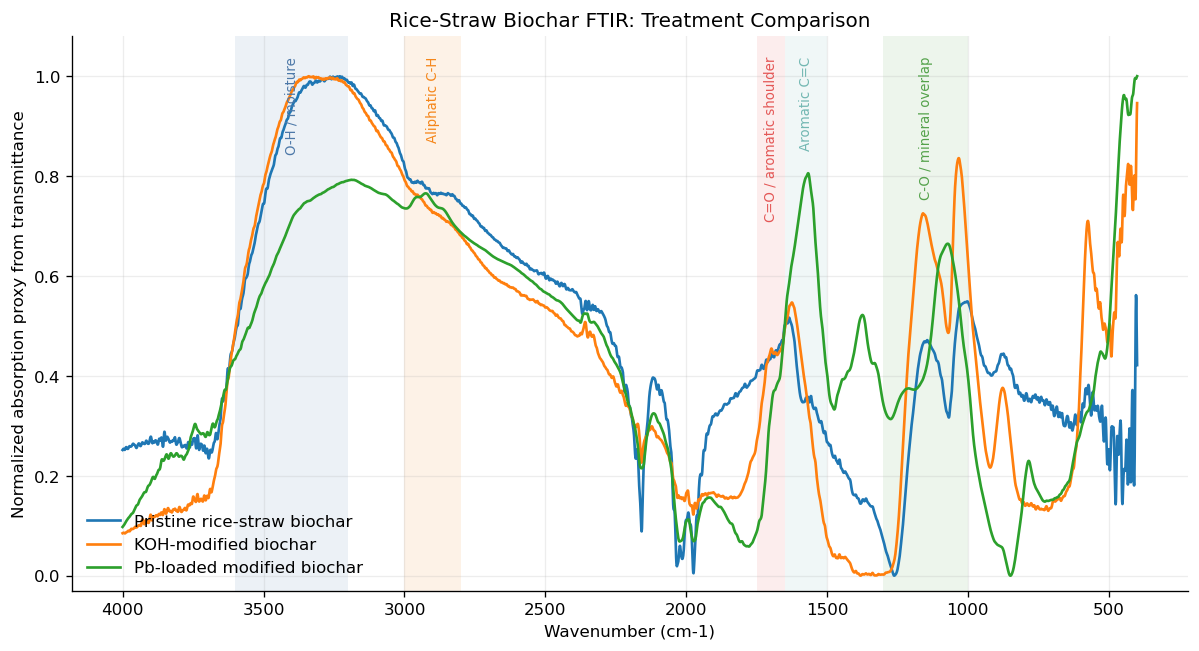

In [9]:
tigalana_dir = RAW_DIR / 'tigalana_mendeley_rice_straw_biochar_pb'
tigalana_files = {
    'Pristine rice-straw biochar': tigalana_dir / 'FTIR-RSB.csv',
    'KOH-modified biochar': tigalana_dir / 'FTIR-KRSB.csv',
    'Pb-loaded modified biochar': tigalana_dir / 'FTIR-KRSB - Pb.csv',
}

tigalana = {}
for label, path in tigalana_files.items():
    df = read_jasco_xy_csv(path)
    df['absorption_proxy'] = 100 - df['transmittance']
    y = df['absorption_proxy'].to_numpy()
    df['normalized_absorption_proxy'] = (y - np.nanmin(y)) / (np.nanmax(y) - np.nanmin(y))
    tigalana[label] = df

fig, ax = plt.subplots(figsize=(12, 6))
for label, df in tigalana.items():
    ax.plot(df['wavenumber'], df['normalized_absorption_proxy'], lw=1.6, label=label)
shade_feature_regions(ax, ymax=1.04)
ax.set_title('Rice-Straw Biochar FTIR: Treatment Comparison')
ax.set_xlabel('Wavenumber (cm-1)')
ax.set_ylabel('Normalized absorption proxy from transmittance')
ax.invert_xaxis()
ax.set_ylim(-0.03, 1.08)
ax.legend(frameon=False, loc='lower left')
save_current_fig('tigalana_biochar_treatment_comparison.png')
plt.show()

## White Charcoal Quality Tables

These are not FTIR spectra, but they help anchor the binchotan/white-charcoal discussion: white charcoal is high fixed-carbon, low volatile material. That supports the expectation of weaker organic functional-group signal than lower-temperature char.

,sample,Moisture content,Ash,Volatile matter,Fixed carbon,Moisture content mean,Ash mean,Volatile matter mean,Fixed carbon mean
0,Charcoal from a modified kiln for thermotheraphy,9.15±0.01,1.50±0.12,9.10±3.75,80.19±3.80,9.15,1.50,9.10,80.19
1,Charcoal from a traditional kiln,9.60±0.04,1.14±0.03,7.06±1.69,82.20±1.68,9.60,1.14,7.06,82.20


Saved /Users/ahmadjalil/github/aethmodular/research/charcoal_ftir/output/plots/white_charcoal_proximate_analysis.png


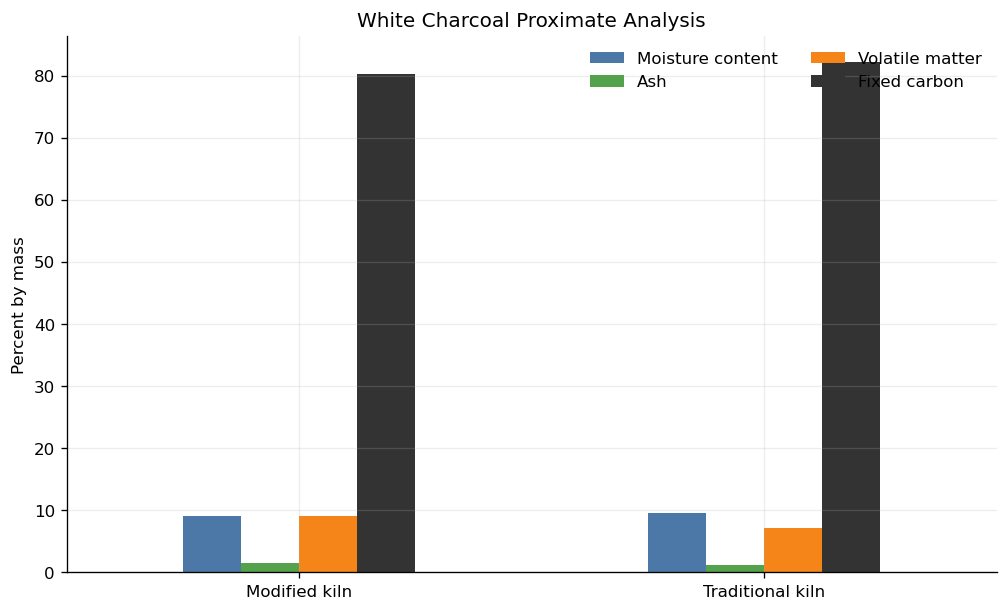

In [10]:
kwon_dir = RAW_DIR / 'kwon_woodj_white_charcoal_quality'
prox = pd.read_html(kwon_dir / 'wood-46-5-527_T1_proximate_analysis.xls')[0]
prox = prox.rename(columns={'Unnamed: 0': 'sample'})
for col in ['Moisture content', 'Ash', 'Volatile matter', 'Fixed carbon']:
    prox[col + ' mean'] = prox[col].map(parse_mean)

display(prox)

plot_cols = ['Moisture content mean', 'Ash mean', 'Volatile matter mean', 'Fixed carbon mean']
fig, ax = plt.subplots(figsize=(10, 5.8))
sample_labels = {
    'Charcoal from a modified kiln for thermotheraphy': 'Modified kiln',
    'Charcoal from a traditional kiln': 'Traditional kiln',
}
prox_plot = prox.assign(sample_short=prox['sample'].map(sample_labels).fillna(prox['sample'])).set_index('sample_short')[plot_cols]
prox_plot.columns = [c.replace(' mean', '') for c in prox_plot.columns]
prox_plot.plot(kind='bar', ax=ax, color=['#4C78A8', '#54A24B', '#F58518', '#333333'])
ax.set_title('White Charcoal Proximate Analysis')
ax.set_ylabel('Percent by mass')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
ax.legend(frameon=False, ncol=2)
save_current_fig('white_charcoal_proximate_analysis.png')
plt.show()

## Optional: Overlay Our Lab KBr Pellet Spectra

When lab spectra are ready, export each scan as CSV with two columns such as `wavenumber, absorbance` or `wavenumber, transmittance`, and place them in `data/interim/lab_spectra/`. The cell below will overlay those spectra with the same feature-region shading.

In [11]:
LAB_DIR = PROJECT_DIR / 'data' / 'interim' / 'lab_spectra'
LAB_DIR.mkdir(parents=True, exist_ok=True)

lab_files = sorted(LAB_DIR.glob('*.csv'))
print(f'Found {len(lab_files)} lab CSV files in {LAB_DIR}')

if lab_files:
    fig, ax = plt.subplots(figsize=(12, 6))
    for path in lab_files:
        df = pd.read_csv(path)
        numeric = df.select_dtypes(include='number')
        if numeric.shape[1] < 2:
            print(f'Skipping {path.name}: need at least two numeric columns')
            continue
        x = numeric.iloc[:, 0].to_numpy(dtype=float)
        y = numeric.iloc[:, 1].to_numpy(dtype=float)
        y_norm = (y - np.nanmin(y)) / (np.nanmax(y) - np.nanmin(y))
        ax.plot(x, y_norm, lw=1.7, label=path.stem)
    shade_feature_regions(ax, ymax=1.04)
    ax.set_title('Lab KBr Pellet Spectra Overlay')
    ax.set_xlabel('Wavenumber (cm-1)')
    ax.set_ylabel('Normalized response')
    ax.invert_xaxis()
    ax.set_ylim(-0.03, 1.08)
    ax.legend(frameon=False)
    save_current_fig('lab_kbr_pellet_overlay.png')
    plt.show()
else:
    print('No lab spectra yet. Add CSV exports when KBr pellet scans are ready.')

Found 0 lab CSV files in /Users/ahmadjalil/github/aethmodular/research/charcoal_ftir/data/interim/lab_spectra
No lab spectra yet. Add CSV exports when KBr pellet scans are ready.


## Presentation Takeaways

- The Dryad charcoal reference data gives a real temperature ladder for interpreting unknown charcoal spectra.
- Feature-region summaries are useful for explaining the chemistry, but final comparisons should use consistently preprocessed spectra and matched measurement mode.
- Tigalana-style before/after spectra are useful examples of how biochar functional groups change with treatment.
- White-charcoal/binchotan literature supports the expectation of high fixed carbon and low volatile matter; Hanmaru appears to be a physical split/shape grade rather than a separate chemistry class.
- The next experimental step is to scan KBr blank, Costco hardwood lump, generic binchotan, and Kishu/Hanmaru binchotan with identical prep and overlay them in this notebook.